# 회귀트리 실습 - 보스턴 주택 가격 예측

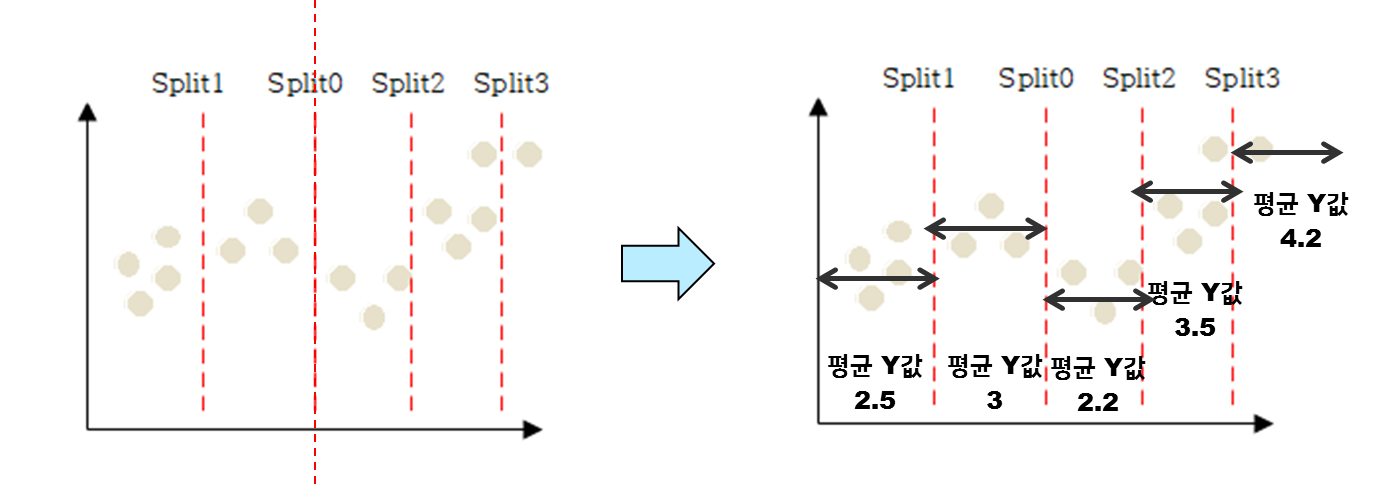

## 사이킷런 Estimator Class

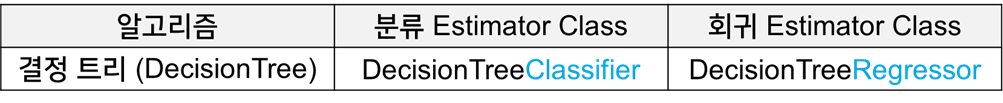

## 1. 라이브러리 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 학습셋과 검증셋의 분리
from sklearn.model_selection import train_test_split  

## 2. 데이터 셋 로드

In [3]:
bostonDF=pd.read_csv('boston.csv')
bostonDF

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


## 3. Feature, Target 설정

In [4]:
#feature
X_features = bostonDF['RM']

In [5]:
#target
y_target= bostonDF['PRICE']
y_target   

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

## 4. 회귀트리(DecisionTreeRegressor)를 이용, 학습/예측

### 4.1) 알고리즘 import

In [6]:
from sklearn.tree import DecisionTreeRegressor

### 4.2) 학습/예측 (max_depth=2)

In [7]:
# 1. estimator생성
dt_reg2 = DecisionTreeRegressor(max_depth=2)

In [8]:
# 2. 학습셋과 검증셋의 분리
X_train , X_val , y_train , y_val = train_test_split(X_features , y_target, test_size=0.3, random_state=156)

- 왜 에러가 났을까? 
- X_features를 어떻게 변경하여야 할까요?

- y_target은 1D-array여도 괜찮은데 왜 X_feaures는 2D-array여야 하는 것일까?
- 일반적으로는 feature는 복수개로 가정-->2D-array

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor.predict

In [9]:
#2D가 되도록 하려면?

X_features = bostonDF[['RM']]

In [10]:
# 2.학습셋과 검증셋의 분리
X_train , X_val , y_train , y_val = train_test_split(X_features , y_target, test_size=0.3, random_state=156)

In [11]:
# 3.학습
dt_reg2.fit(X_train , y_train)

DecisionTreeRegressor(max_depth=2)

In [12]:
# 4. 예측
pred_dt2 = dt_reg2.predict(X_val)
pred_dt2 #예측값

array([19.15546875, 19.15546875, 32.640625  , 19.15546875, 26.07674419,
       19.15546875, 19.15546875, 19.15546875, 19.15546875, 19.15546875,
       19.15546875, 19.15546875, 26.07674419, 45.23913043, 19.15546875,
       19.15546875, 32.640625  , 19.15546875, 26.07674419, 19.15546875,
       19.15546875, 19.15546875, 19.15546875, 19.15546875, 32.640625  ,
       19.15546875, 19.15546875, 19.15546875, 19.15546875, 19.15546875,
       26.07674419, 19.15546875, 19.15546875, 19.15546875, 19.15546875,
       26.07674419, 19.15546875, 26.07674419, 19.15546875, 19.15546875,
       32.640625  , 19.15546875, 26.07674419, 19.15546875, 19.15546875,
       19.15546875, 32.640625  , 45.23913043, 19.15546875, 19.15546875,
       26.07674419, 45.23913043, 45.23913043, 26.07674419, 26.07674419,
       19.15546875, 19.15546875, 32.640625  , 19.15546875, 19.15546875,
       19.15546875, 19.15546875, 19.15546875, 19.15546875, 19.15546875,
       45.23913043, 32.640625  , 19.15546875, 26.07674419, 19.15

In [13]:
y_val #실제값

210    21.7
15     19.9
264    36.5
396    12.5
234    29.0
       ... 
393    13.8
325    24.6
53     23.4
401     7.2
178    29.9
Name: PRICE, Length: 152, dtype: float64

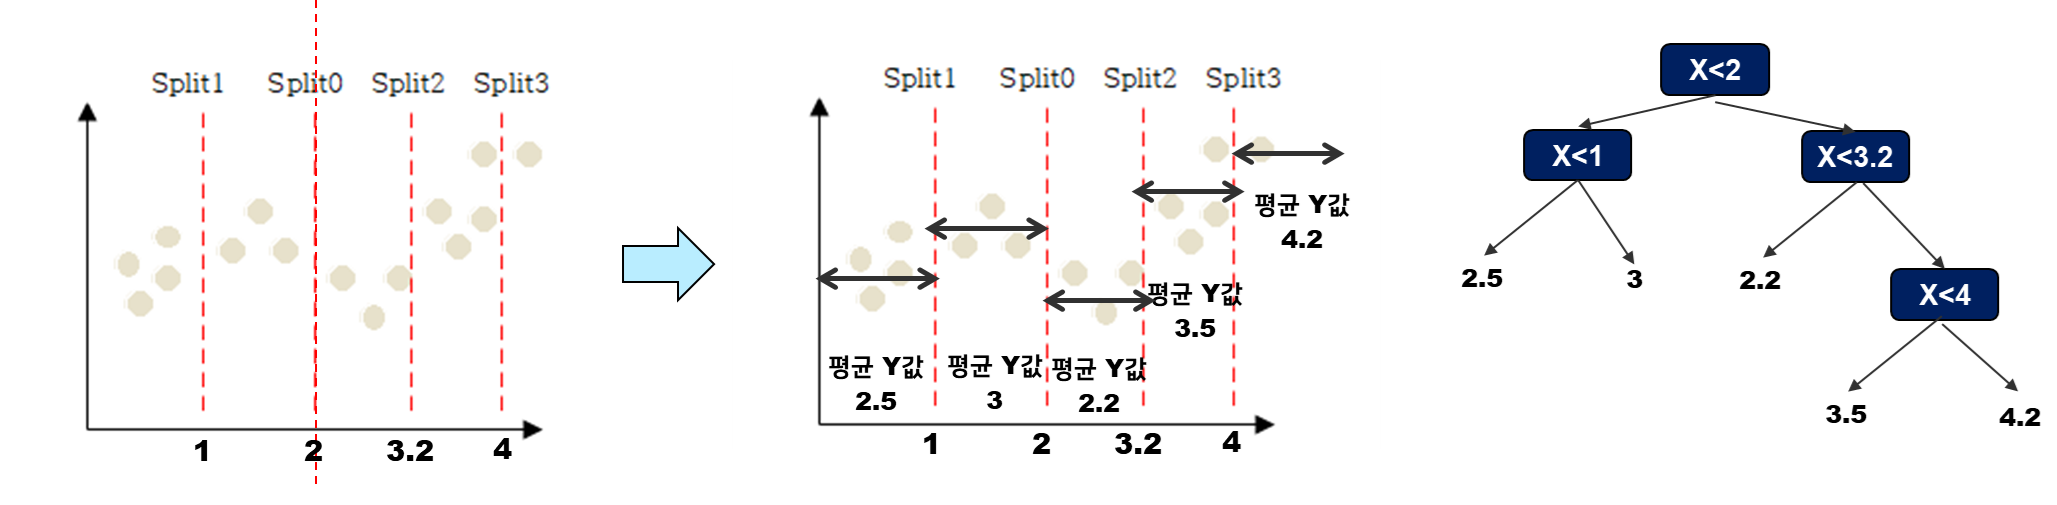

### 4.3) 학습/예측 (max_depth=7)

In [14]:
# 1. estimator생성
dt_reg7 =DecisionTreeRegressor(max_depth=7)

In [15]:
# 2. 학습
dt_reg7.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=7)

In [16]:
# 3. 예측
pred_dt7 = dt_reg7.predict(X_val)
pred_dt7  #예측값

array([17.915625  , 14.04      , 34.72727273, 20.56164384, 25.15384615,
       20.56164384, 20.74285714, 11.97777778, 11.97777778, 17.915625  ,
       20.56164384, 17.915625  , 25.4       , 43.8       , 20.74285714,
       20.56164384, 35.4       , 18.125     , 25.4       , 15.06      ,
       20.56164384, 17.915625  , 18.125     , 18.125     , 37.        ,
       13.85555556, 20.74285714, 50.        , 18.125     , 15.23846154,
       25.4       , 20.56164384, 17.915625  , 20.74285714, 27.42      ,
       25.4       , 15.23846154, 17.45      , 18.125     , 20.56164384,
       34.72727273, 20.56164384, 29.4       , 13.85555556, 20.56164384,
       17.915625  , 37.        , 43.4       , 20.56164384, 20.56164384,
       25.4       , 43.8       , 43.4       , 17.45      , 25.15384615,
       20.56164384, 20.56164384, 33.2       , 20.74285714, 18.125     ,
       33.7       , 20.56164384, 20.56164384, 11.97777778, 20.32857143,
       47.        , 34.72727273, 27.42      , 31.6       , 17.91

In [17]:
y_val #실제값

210    21.7
15     19.9
264    36.5
396    12.5
234    29.0
       ... 
393    13.8
325    24.6
53     23.4
401     7.2
178    29.9
Name: PRICE, Length: 152, dtype: float64

## 5. Linear Regression을 이용 학습/예측

### 5.1) 알고리즘 import

In [18]:
from sklearn.linear_model import LinearRegression

### 5.2) 학습/예측

In [19]:
# 1. estimator생성
lr_reg = LinearRegression()

In [20]:
#2. 학습
lr_reg.fit(X_train, y_train)

LinearRegression()

In [21]:
#3. 예측
pred_lr = lr_reg.predict(X_val)
pred_lr #예측값

array([20.03518372, 18.91902441, 31.07275913, 23.97717493, 26.82072366,
       23.35708643, 21.82458198, 14.57840486, 11.85001544, 20.17691823,
       24.67698911, 19.36194477, 25.75771479, 40.29436105, 20.66413063,
       23.77343157, 28.9644582 , 17.84715713, 25.48310416, 20.42495364,
       22.41809526, 19.73399787, 17.79400669, 18.14834298, 28.81386528,
        8.44838706, 21.30193595, 11.29193578, 16.89044915, 15.19849337,
       25.61598027, 24.45552892, 19.93774124, 20.59326337, 22.23206871,
       25.96145815, 16.27921905, 26.20949356, 17.8117235 , 23.27736076,
       30.19577681, 24.23406874, 25.21735195,  7.2702189 , 24.41123689,
       20.06175894, 28.86701573, 35.3247946 , 22.42695367, 22.59526341,
       25.66027231, 40.73728141, 36.35236983, 26.19177674, 26.82958206,
       23.56082979, 24.77443159, 32.89759101, 21.62969702, 16.53611286,
       19.2733607 , 24.96045814, 22.55982978, 13.98489158, 18.28121909,
       33.41137863, 30.82472372, 22.25864393, 27.68884756, 20.26

In [22]:
y_val #실제값

210    21.7
15     19.9
264    36.5
396    12.5
234    29.0
       ... 
393    13.8
325    24.6
53     23.4
401     7.2
178    29.9
Name: PRICE, Length: 152, dtype: float64

## 6. 결과 시각화

### 6.1) 회귀트리(max_depth=2)로 학습된 모델의 회귀 예측선 

In [33]:
X_val['RM']

210    5.960
15     5.834
264    7.206
396    6.405
234    6.726
       ...  
393    6.193
325    6.431
53     5.998
401    6.343
178    6.860
Name: RM, Length: 152, dtype: float64

In [26]:
y_val

210    21.7
15     19.9
264    36.5
396    12.5
234    29.0
       ... 
393    13.8
325    24.6
53     23.4
401     7.2
178    29.9
Name: PRICE, Length: 152, dtype: float64

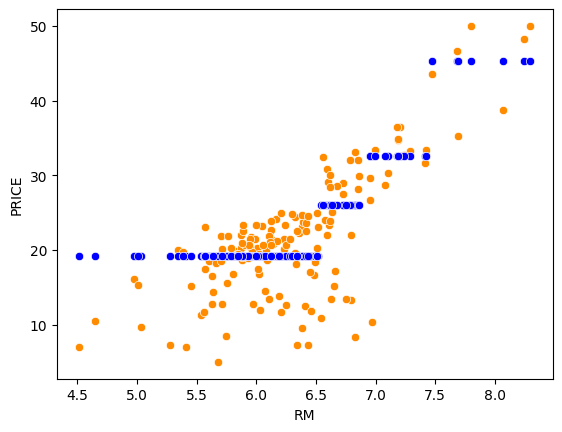

In [36]:
plt.title('Decision Tree Regression: max_depth=2')
sns.scatterplot(x=X_val['RM'], y=y_val, c="darkorange")    #실제 데이터
sns.scatterplot(x=X_val['RM'], y=pred_dt2, c="blue")       #예측 데이터
plt.show()

### 6.2) 회귀트리(max_depth=7)로 학습된 모델의 회귀 예측선 

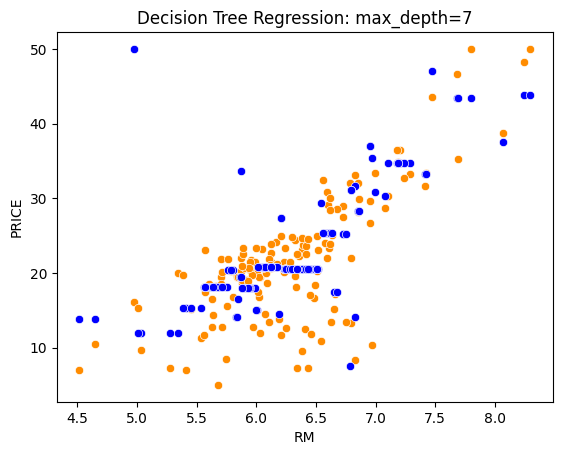

In [37]:
plt.title('Decision Tree Regression: max_depth=7')
sns.scatterplot(x=X_val['RM'], y=y_val, c="darkorange")    #실제 데이터
sns.scatterplot(x=X_val['RM'], y=pred_dt7, c="blue")       #예측 데이터
plt.show()

### 6.3)선형 회귀로 학습된 모델의 회귀 예측선 

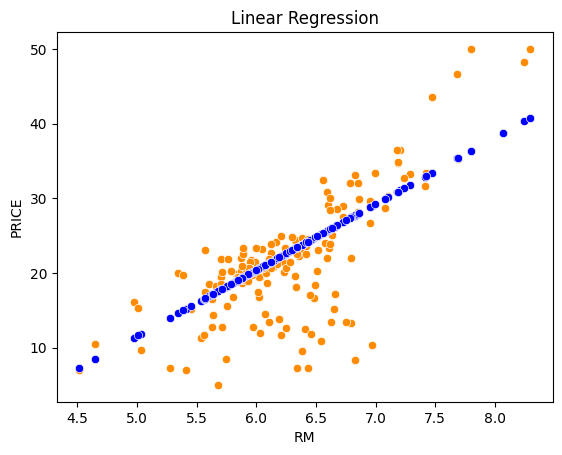

In [38]:
plt.title('Linear Regression')
sns.scatterplot(x=X_val['RM'], y=y_val, c="darkorange")    #실제 데이터
sns.scatterplot(x=X_val['RM'], y=pred_lr, c="blue")       #예측 데이터
plt.show()

* **선형회귀는 직선으로 예측회귀선을 표현**
* **회귀 트리는 분할되는 데이터 지점에 따라 브랜치를 만들면서 계단 형태로 회귀선 생성**
* **max_depth=7의 경우, 이상치 데이터도 반복학습하여 복잡한 계단형 회귀선 생성, 과대적합 가능성**